In [105]:
from config import client
import pandas as pd

In [106]:
customers_query = """
SELECT * FROM zoho_books_analytics.customers
"""

result = client.query(customers_query)

customers_df = pd.DataFrame(result.result_rows, columns=[col for col in result.column_names])

In [121]:
customers_df.head()

,customer_name,status,payment_terms,currency_code,last_modified_time,created_time,created_by,credit_limit,customer_sub_type,bank_account_payment,customer_category,sales_category,sales_person,credit_insurance
0,ABC Supermarket,Active,Net 30,USD,2025-02-11 20:14:57+00:00,2018-07-24 02:28:15+00:00,1410873000000065001,0.00,business,No,Retailer,No Sales Category,Ned Ligenza,No Credit Insurance
1,"ALCHEMY SIMYA, INC.",Active,Due On Receipt,USD,2024-05-01 17:57:29+00:00,2018-07-24 02:28:15+00:00,1410873000000065001,0.00,business,No,Empty Value,No Sales Category,No Sales Person,No Credit Insurance
2,"Aldi, Inc.",Active,Net 30,USD,2025-06-19 14:15:45+00:00,2018-07-24 02:28:15+00:00,1410873000000065001,0.00,business,No,Retailer,No Sales Category,Chow,No Credit Insurance
3,Amende & Schultz Inc,Active,TTR 100% WITHIN 3 DAYS AFTER FDA PASSED BUT P...,USD,2024-05-01 17:57:29+00:00,2018-07-24 02:28:15+00:00,1410873000000065001,0.00,business,No,Food Service,No Sales Category,No Sales Person,No Credit Insurance
4,"Anderson Seafoods, Inc.",Active,Net 30,USD,2025-06-19 14:15:43+00:00,2018-07-24 02:28:15+00:00,1410873000000065001,"300,000.00",business,No,Wholesale,No Sales Category,Ned Ligenza,No Credit Insurance


In [122]:
customers_df.columns

Index(['customer_name', 'status', 'payment_terms', 'currency_code',
       'last_modified_time', 'created_time', 'created_by', 'credit_limit',
       'customer_sub_type', 'bank_account_payment', 'customer_category',
       'sales_category', 'sales_person', 'credit_insurance'],
      dtype='object')

In [ ]:
columns_to_drop = ['customer_id','display_name','company_name','email','phone','crm_reference_id','salutation','first_name','last_name','mobile_phone','notes','website','marked_as_completed','push_to_crm','portal_enabled','modified_by','apn_code','test','customer_number','customer_owner_id','default_address_id','pricelist_id','apn_codeid','testid','currency_code','bank_account_payment','source','qb_id','commission_company','sales_manager']
customers_df = customers_df.drop(columns=columns_to_drop)

In [110]:
customers_df[['credit_insurance','customer_name']].value_counts()

credit_insurance  customer_name                                  
                  NORTHERN-HASEROT COMPANY                           2
                  ZF America                                         2
                  INSTITUTION FOOD HOUSE, INC                        2
                  +                                                  1
                  Seve's Meats, Inc. dba Florence Meats Wholesale    1
                                                                    ..
                  KETTLE CUISINE                                     1
                  KING WHOLESALE                                     1
                  KK Film Networks                                   1
                  KOT Wholesale                                      1
500000            Conexus Food Solutions                             1
Name: count, Length: 699, dtype: int64

In [111]:
customers_df['credit_limit'] = customers_df['credit_limit'].str.replace('USD', '').str.strip()

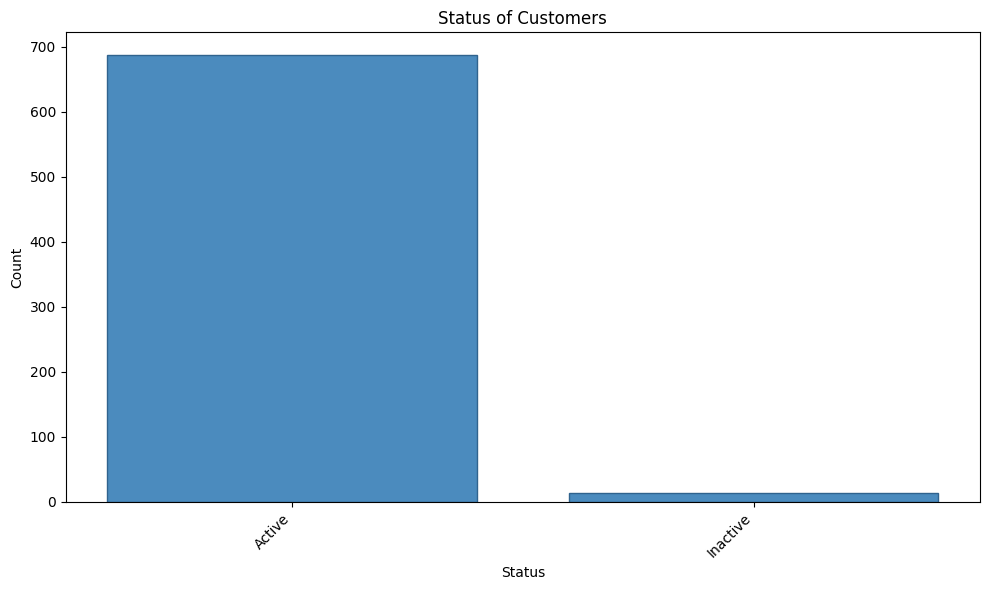

In [112]:
from graph import plot_bar_graph
plot_bar_graph(customers_df['status'], title="Status of Customers", x_label="Status", y_label="Count")

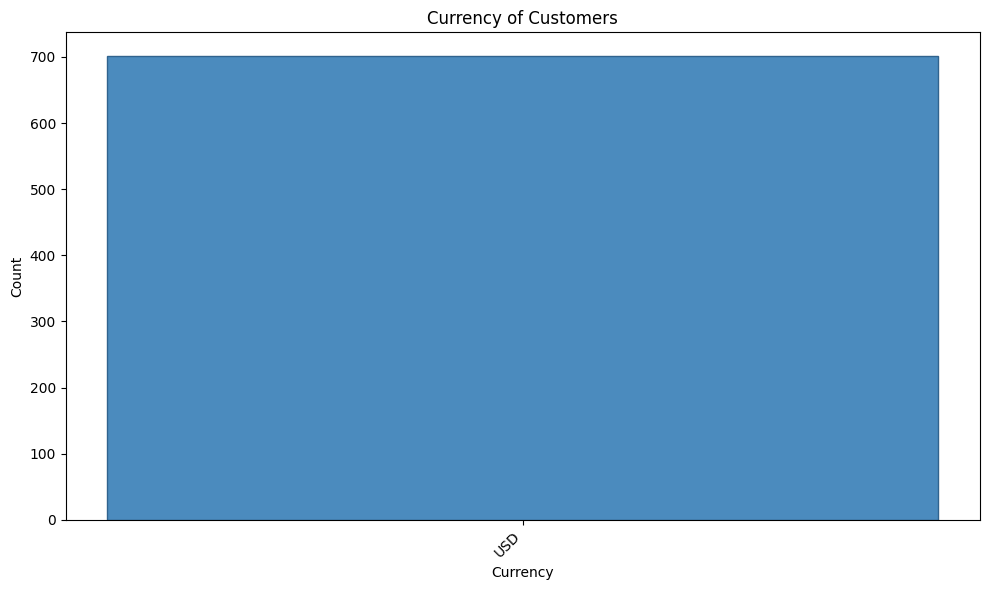

In [113]:
plot_bar_graph(customers_df['currency_code'], title="Currency of Customers", x_label="Currency", y_label="Count")

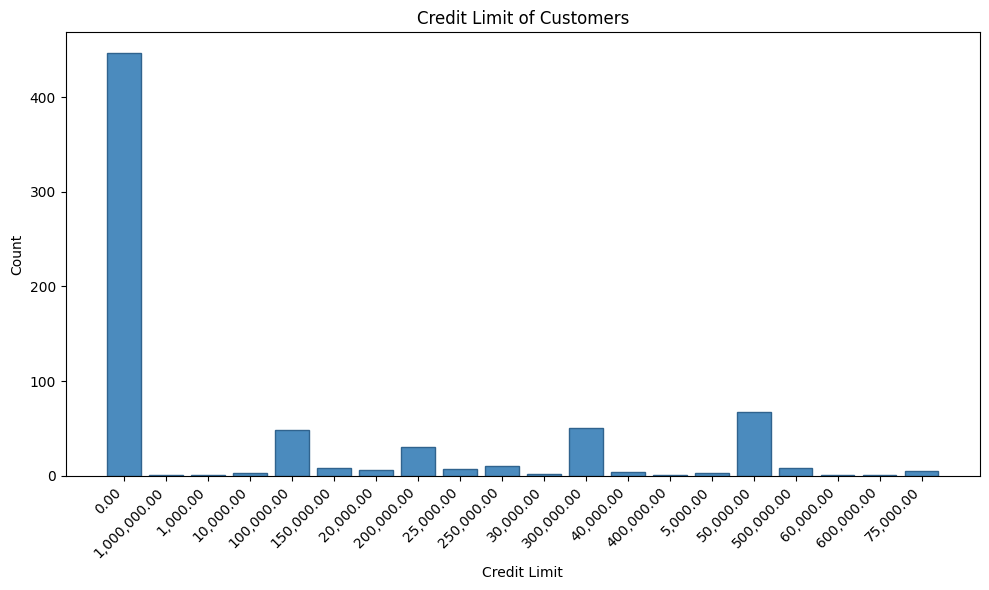

In [114]:
plot_bar_graph(customers_df['credit_limit'], title="Credit Limit of Customers", x_label="Credit Limit", y_label="Count")

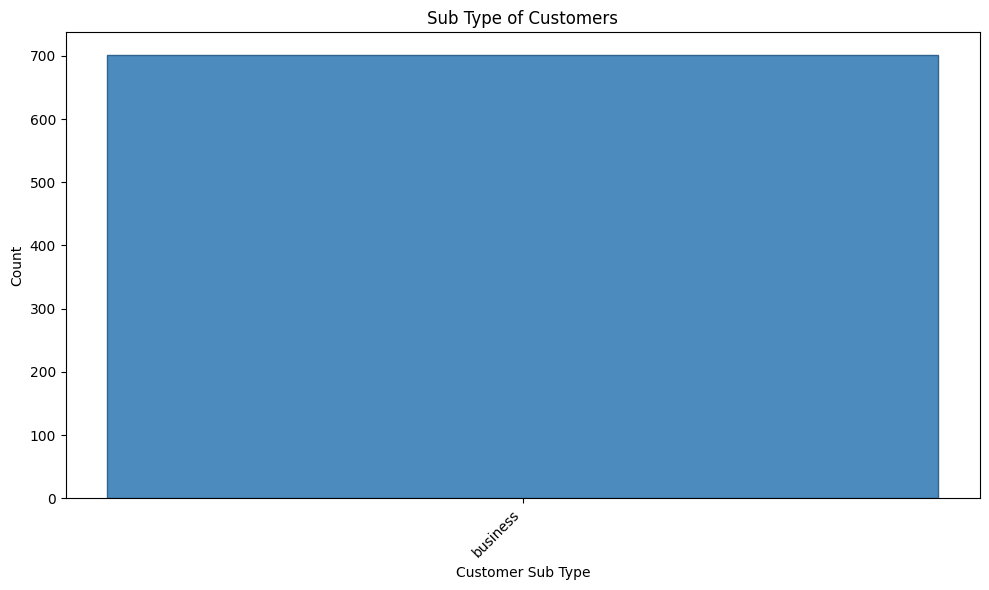

In [123]:
plot_bar_graph(customers_df['customer_sub_type'], title="Sub Type of Customers", x_label="Customer Sub Type", y_label="Count")

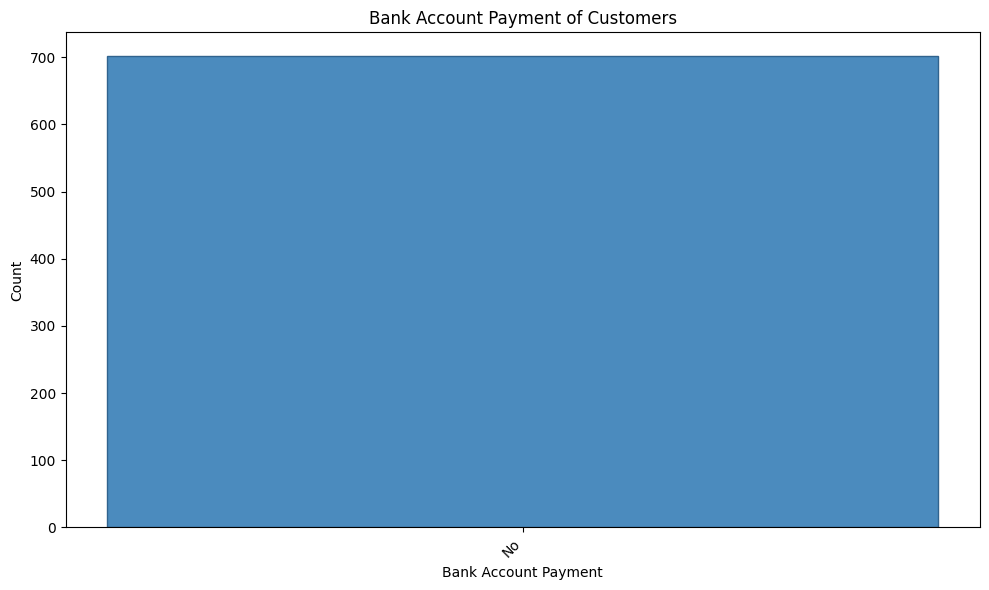

In [116]:
plot_bar_graph(customers_df['bank_account_payment'], title="Bank Account Payment of Customers", x_label="Bank Account Payment", y_label="Count")

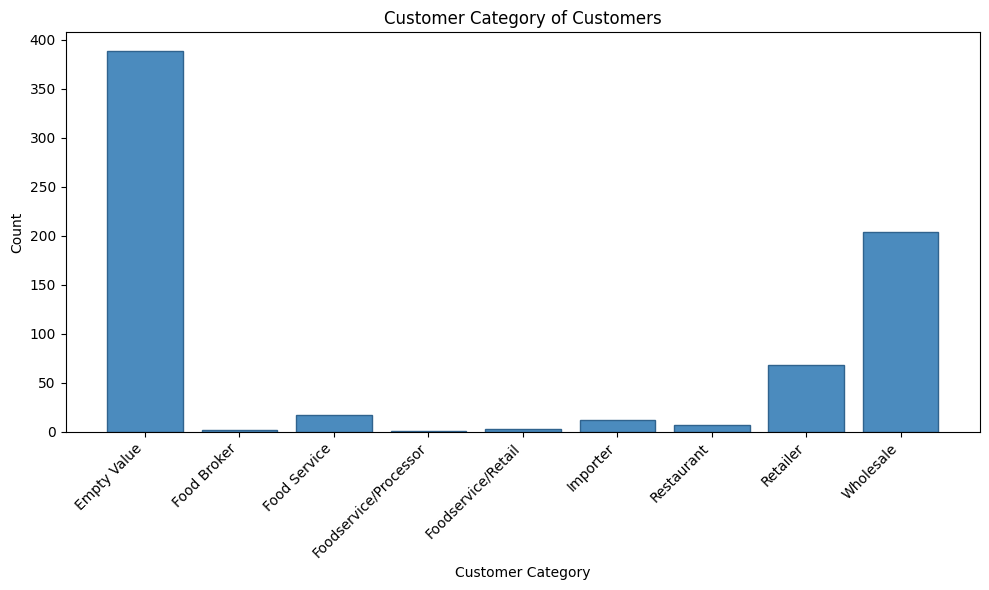

In [ ]:
customers_df['customer_category'] = customers_df['customer_category'].replace('', 'No Customer Category')
plot_bar_graph(customers_df['customer_category'], title="Category of Customers", x_label="Customer Category", y_label="Count")

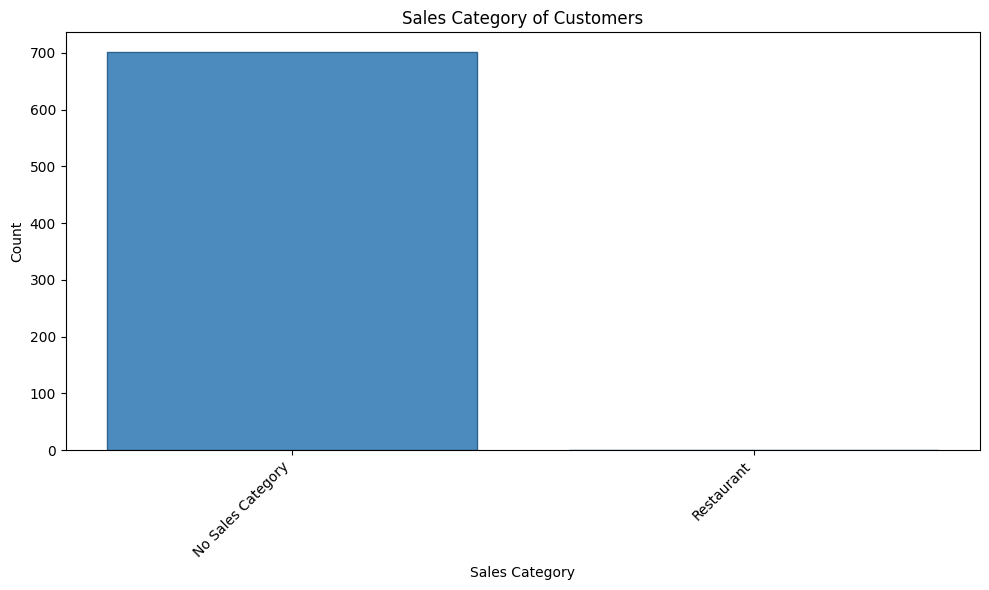

In [118]:
customers_df['sales_category'] = customers_df['sales_category'].replace('', 'No Sales Category')
plot_bar_graph(customers_df['sales_category'], title="Sales Category of Customers", x_label="Sales Category", y_label="Count")

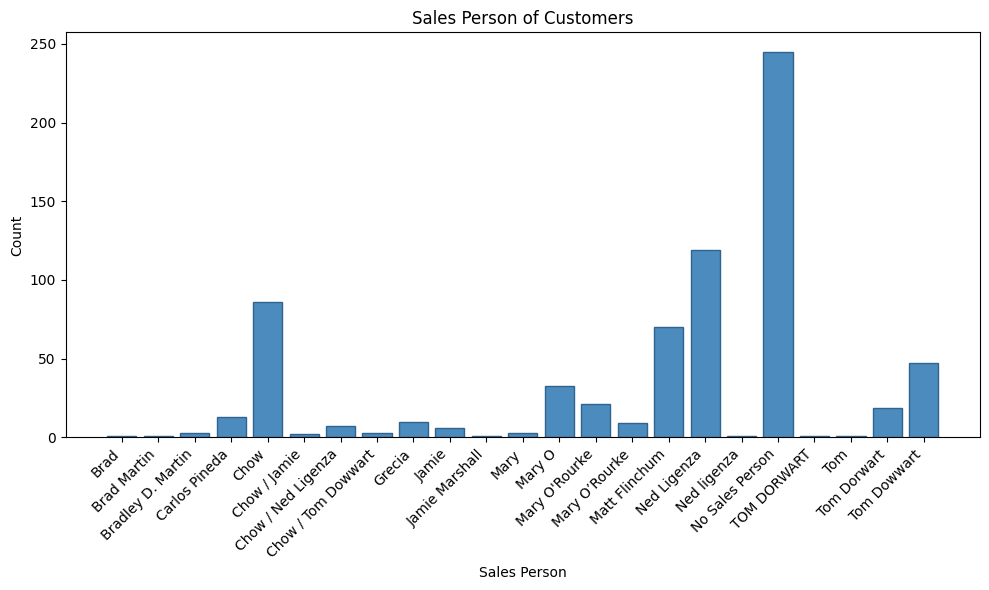

In [119]:
customers_df['sales_person'] = customers_df['sales_person'].replace('', 'No Sales Person')
plot_bar_graph(customers_df['sales_person'], title="Sales Person of Customers", x_label="Sales Person", y_label="Count")

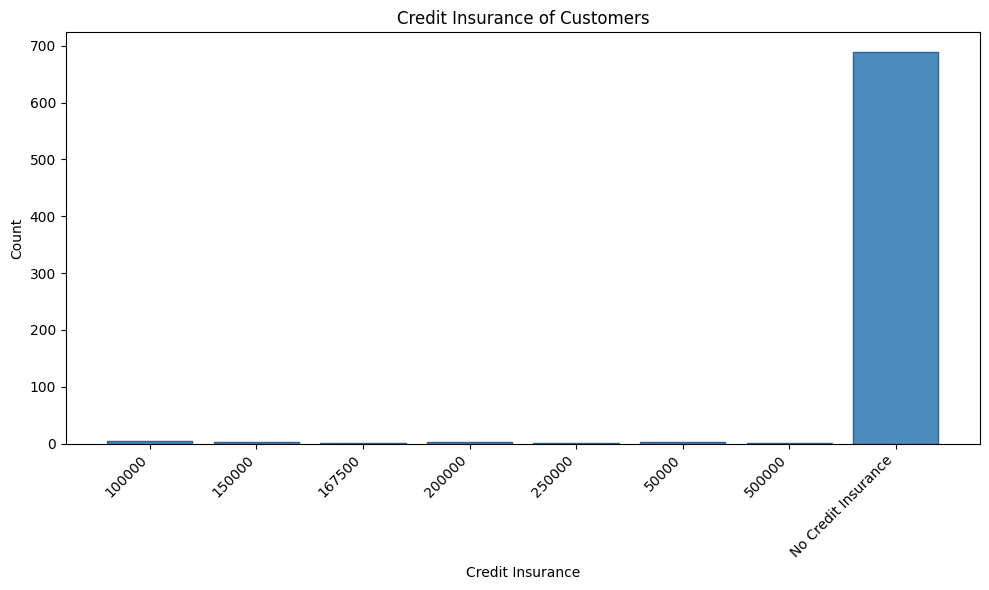

In [120]:
customers_df['credit_insurance'] = customers_df['credit_insurance'].replace('', 'No Credit Insurance')
plot_bar_graph(customers_df['credit_insurance'], title="Credit Insurance of Customers", x_label="Credit Insurance", y_label="Count")